# Q1 2025 baseline vs Quick ML vs Optimized ML

This notebook compares the source ETA/ETD forecast, a train-only statistical correction, fixed Quick ML, and a constrained Optimized ML search on March 2025 events. It continues the point-in-time eligibility contract from Notebook 03.

Source: Fintraffic Digitraffic Port Call API, [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). These experiments use public source estimates and do not evaluate a Portcast model.

## Question and experiment contract

Can information available when an ETA or ETD is recorded reduce forecast error on the following month, and does constrained optimization add enough value over a fixed Quick ML model?

- Evaluation grain: one canonical event per milestone (`arrival` or `departure`).
- January is the development period, February is the validation period, and March is the evaluation period.
- Target: `actual_time - source_forecast_time`, in hours. The adjusted forecast adds the predicted residual to the source forecast.
- Source, statistical, Quick ML, and Optimized ML methods are scored on the same March rows.
- A forecast is eligible only when it was recorded before or at the actual milestone.
- The ±6, ±12, and ±24 hour bands are descriptive review thresholds, not service-level targets.

In [1]:
from base64 import b64encode
from io import BytesIO
from pathlib import Path
from time import perf_counter

import duckdb
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, ParameterGrid, PredefinedSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

pd.set_option('display.max_columns', 30)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
def find_data_dir():
    for folder in (Path.cwd(), *Path.cwd().parents):
        candidate = folder / 'data' / 'q1-2025'
        if (candidate / 'port_area_details.csv').exists():
            return candidate
    raise FileNotFoundError('Q1 CSV snapshot not found. Run from the project directory after cloning the repository.')

data_dir = find_data_dir()
source_details = pd.read_csv(data_dir / 'port_area_details.csv')
canonical_events = pd.read_csv(data_dir / 'canonical_port_area_events.csv')

connection = duckdb.connect()
connection.execute("SET TimeZone = 'UTC'")
connection.register('source_details', source_details)
connection.register('canonical_events', canonical_events)

print(f'Loaded {len(source_details):,} source rows and {len(canonical_events):,} canonical events.')

Loaded 7,176 source rows and 7,172 canonical events.


## 1. Build the point-in-time population

The query applies the same canonical join and latest eligible forecast rule as Notebook 03. It retains source positions for error review and adds vessel type for modelling.

In [3]:
evaluation_query = r"""
WITH linked_source AS (
    SELECT
        c.canonical_event_id,
        c.port_call_id,
        c.port_code,
        c.vessel_type_code,
        c.port_area_code,
        c.berth_code,
        s.source_chunk,
        s.response_index,
        s.area_sequence,
        TRY_CAST(s.ata AS TIMESTAMPTZ) AS ata,
        TRY_CAST(s.atd AS TIMESTAMPTZ) AS atd,
        TRY_CAST(s.eta AS TIMESTAMPTZ) AS eta,
        TRY_CAST(s.etd AS TIMESTAMPTZ) AS etd,
        TRY_CAST(s.eta_timestamp AS TIMESTAMPTZ) AS eta_timestamp,
        TRY_CAST(s.etd_timestamp AS TIMESTAMPTZ) AS etd_timestamp,
        s.eta_source,
        s.etd_source
    FROM source_details AS s
    INNER JOIN canonical_events AS c
        ON s.port_call_id = c.port_call_id
        AND COALESCE(s.port_code, '') = COALESCE(c.port_code, '')
        AND COALESCE(s.port_area_code, '') = COALESCE(c.port_area_code, '')
        AND COALESCE(s.berth_code, '') = COALESCE(c.berth_code, '')
        AND COALESCE(s.ata, '') = COALESCE(c.ata, '')
        AND COALESCE(s.atd, '') = COALESCE(c.atd, '')
),
forecast_candidates AS (
    SELECT
        canonical_event_id, port_call_id, port_code, vessel_type_code, port_area_code, berth_code,
        source_chunk, response_index, area_sequence, 'arrival' AS milestone,
        ata AS actual_time, eta AS forecast_time, eta_timestamp AS forecast_recorded_time,
        eta_source AS forecast_source
    FROM linked_source

    UNION ALL

    SELECT
        canonical_event_id, port_call_id, port_code, vessel_type_code, port_area_code, berth_code,
        source_chunk, response_index, area_sequence, 'departure' AS milestone,
        atd AS actual_time, etd AS forecast_time, etd_timestamp AS forecast_recorded_time,
        etd_source AS forecast_source
    FROM linked_source
),
event_flags AS (
    SELECT
        canonical_event_id, port_call_id, port_code, vessel_type_code, port_area_code, berth_code, milestone,
        MAX(actual_time) AS actual_time,
        MAX(CASE WHEN forecast_time IS NOT NULL THEN 1 ELSE 0 END) AS has_forecast,
        MAX(CASE WHEN forecast_time IS NOT NULL AND forecast_recorded_time IS NOT NULL THEN 1 ELSE 0 END) AS has_forecast_timestamp,
        SUM(CASE WHEN forecast_time IS NOT NULL AND forecast_recorded_time <= actual_time THEN 1 ELSE 0 END) AS valid_forecast_count,
        SUM(CASE WHEN forecast_time IS NOT NULL AND forecast_recorded_time > actual_time THEN 1 ELSE 0 END) AS post_actual_forecast_count
    FROM forecast_candidates
    GROUP BY ALL
),
valid_forecasts AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY canonical_event_id, milestone
            ORDER BY forecast_recorded_time DESC, source_chunk, response_index, area_sequence
        ) AS forecast_rank
    FROM forecast_candidates
    WHERE actual_time IS NOT NULL
      AND forecast_time IS NOT NULL
      AND forecast_recorded_time IS NOT NULL
      AND forecast_recorded_time <= actual_time
)
SELECT
    f.canonical_event_id, f.port_call_id, f.port_code, f.vessel_type_code, f.port_area_code, f.berth_code,
    f.milestone,
    CASE
        WHEN f.actual_time IS NULL THEN 'blocked_missing_actual'
        WHEN f.has_forecast = 0 THEN 'blocked_missing_forecast'
        WHEN f.has_forecast_timestamp = 0 THEN 'blocked_missing_forecast_timestamp'
        WHEN f.valid_forecast_count = 0 AND f.post_actual_forecast_count > 0 THEN 'blocked_post_actual_forecast_only'
        WHEN f.valid_forecast_count = 0 THEN 'blocked_no_valid_pre_actual_forecast'
        ELSE 'eligible'
    END AS evaluation_status,
    v.forecast_source, v.source_chunk, v.response_index, v.area_sequence,
    f.actual_time, v.forecast_time, v.forecast_recorded_time,
    DATE_DIFF('second', v.forecast_time, f.actual_time) / 3600.0 AS target_residual_hours,
    DATE_DIFF('second', v.forecast_recorded_time, v.forecast_time) / 3600.0 AS forecast_horizon_hours
FROM event_flags AS f
LEFT JOIN valid_forecasts AS v
    ON f.canonical_event_id = v.canonical_event_id
    AND f.milestone = v.milestone
    AND v.forecast_rank = 1
ORDER BY f.canonical_event_id, f.milestone
"""

evaluation = connection.execute(evaluation_query).df()

population_check = pd.Series({
    'canonical_events': evaluation['canonical_event_id'].nunique(),
    'expected_milestone_rows': len(canonical_events) * 2,
    'evaluation_rows': len(evaluation),
    'duplicate_event_milestone_rows': evaluation.duplicated(['canonical_event_id', 'milestone']).sum(),
})
display(population_check)

if population_check['evaluation_rows'] != population_check['expected_milestone_rows']:
    raise ValueError('Point-in-time population does not reconcile to canonical events.')
if population_check['duplicate_event_milestone_rows'] != 0:
    raise ValueError('Point-in-time population contains duplicate event-milestone rows.')

canonical_events                   7172
expected_milestone_rows           14344
evaluation_rows                   14344
duplicate_event_milestone_rows        0
dtype: int64

## 2. Temporal split and leakage audit

The model uses location, vessel, source, calendar, and forecast-horizon fields available at forecast time. `actual_time` is used only to define the temporal split and target; it is never passed to either model. The forecast horizon is `forecast_time - forecast_recorded_time`, not an actual-derived lead time. Arrival and departure remain separate experiments, so milestone is a partition key rather than a model feature.

In [4]:
eligible = evaluation.query("evaluation_status == 'eligible'").copy()

horizon_labels = ['negative', '0–24 hours', '24–72 hours', '3–7 days', '7+ days']
eligible['forecast_horizon_band'] = pd.cut(
    eligible['forecast_horizon_hours'],
    bins=[float('-inf'), 0, 24, 72, 168, float('inf')],
    labels=horizon_labels,
    include_lowest=True,
)
eligible['forecast_hour'] = eligible['forecast_time'].dt.hour
eligible['forecast_day_of_week'] = eligible['forecast_time'].dt.dayofweek
eligible['recorded_hour'] = eligible['forecast_recorded_time'].dt.hour
eligible['recorded_day_of_week'] = eligible['forecast_recorded_time'].dt.dayofweek
eligible['forecast_horizon_signed_log1p'] = (
    np.sign(eligible['forecast_horizon_hours']) * np.log1p(eligible['forecast_horizon_hours'].abs())
)
eligible['negative_forecast_horizon'] = eligible['forecast_horizon_hours'].lt(0).astype(int)
eligible['forecast_hour_sin'] = np.sin(2 * np.pi * eligible['forecast_hour'] / 24)
eligible['forecast_hour_cos'] = np.cos(2 * np.pi * eligible['forecast_hour'] / 24)
eligible['recorded_hour_sin'] = np.sin(2 * np.pi * eligible['recorded_hour'] / 24)
eligible['recorded_hour_cos'] = np.cos(2 * np.pi * eligible['recorded_hour'] / 24)
eligible['forecast_weekday_sin'] = np.sin(2 * np.pi * eligible['forecast_day_of_week'] / 7)
eligible['forecast_weekday_cos'] = np.cos(2 * np.pi * eligible['forecast_day_of_week'] / 7)
eligible['recorded_weekday_sin'] = np.sin(2 * np.pi * eligible['recorded_day_of_week'] / 7)
eligible['recorded_weekday_cos'] = np.cos(2 * np.pi * eligible['recorded_day_of_week'] / 7)

development_mask = eligible['actual_time'].between('2025-01-01', '2025-02-01', inclusive='left')
validation_mask = eligible['actual_time'].between('2025-02-01', '2025-03-01', inclusive='left')
train_mask = development_mask | validation_mask
test_mask = eligible['actual_time'].between('2025-03-01', '2025-04-01', inclusive='left')
eligible['split'] = 'outside_experiment_window'
eligible.loc[development_mask, 'split'] = 'development'
eligible.loc[validation_mask, 'split'] = 'validation'
eligible.loc[test_mask, 'split'] = 'evaluation'

split_summary = (
    eligible.groupby(['milestone', 'split'], as_index=False)
    .agg(events=('canonical_event_id', 'size'), min_actual=('actual_time', 'min'), max_actual=('actual_time', 'max'))
)
display(split_summary)

development_keys = set(eligible.loc[development_mask, 'canonical_event_id'] + '|' + eligible.loc[development_mask, 'milestone'])
validation_keys = set(eligible.loc[validation_mask, 'canonical_event_id'] + '|' + eligible.loc[validation_mask, 'milestone'])
test_keys = set(eligible.loc[test_mask, 'canonical_event_id'] + '|' + eligible.loc[test_mask, 'milestone'])
if development_keys & validation_keys or development_keys & test_keys or validation_keys & test_keys:
    raise ValueError('Development, validation, and March populations overlap.')

,milestone,split,events,min_actual,max_actual
0,arrival,development,2220,2025-01-01 00:00:00+00:00,2025-01-31 23:05:00+00:00
1,arrival,evaluation,2408,2025-03-01 00:00:00+00:00,2025-03-31 23:20:00+00:00
2,arrival,validation,2265,2025-02-01 00:00:00+00:00,2025-02-28 23:05:00+00:00
3,departure,development,2129,2025-01-01 00:10:00+00:00,2025-01-31 23:10:00+00:00
4,departure,evaluation,2375,2025-03-01 00:05:00+00:00,2025-03-31 23:10:00+00:00
5,departure,outside_experiment_window,83,2025-04-01 00:02:00+00:00,2026-08-14 13:25:00+00:00
6,departure,validation,2212,2025-02-01 00:10:00+00:00,2025-02-28 23:10:00+00:00


In [5]:
categorical_features = [
    'port_code', 'port_area_code', 'berth_code', 'vessel_type_code', 'forecast_source',
]
quick_numeric_features = [
    'forecast_horizon_hours', 'forecast_hour', 'forecast_day_of_week',
    'recorded_hour', 'recorded_day_of_week',
]
optimized_numeric_features = [
    'forecast_horizon_signed_log1p', 'negative_forecast_horizon',
    'forecast_hour_sin', 'forecast_hour_cos', 'recorded_hour_sin', 'recorded_hour_cos',
    'forecast_weekday_sin', 'forecast_weekday_cos',
    'recorded_weekday_sin', 'recorded_weekday_cos',
]
quick_features = categorical_features + quick_numeric_features
optimized_features = categorical_features + optimized_numeric_features
prohibited_features = {
    'actual_time', 'target_residual_hours', 'ata', 'atd', 'ata_source', 'atd_source',
    'ata_timestamp', 'atd_timestamp', 'lead_time_hours', 'source_chunk', 'milestone',
}
leaked_quick_features = sorted(set(quick_features) & prohibited_features)
leaked_optimized_features = sorted(set(optimized_features) & prohibited_features)

feature_audit = pd.concat([
    pd.DataFrame({'model': 'Quick ML', 'feature': quick_features}),
    pd.DataFrame({'model': 'Optimized ML', 'feature': optimized_features}),
], ignore_index=True)
feature_audit['available_at_forecast_time'] = True
display(feature_audit)

if leaked_quick_features or leaked_optimized_features:
    raise ValueError('Prohibited model features detected.')
if eligible.loc[development_mask, 'actual_time'].max() >= eligible.loc[validation_mask, 'actual_time'].min():
    raise ValueError('Development and validation windows overlap.')
if eligible.loc[validation_mask, 'actual_time'].max() >= eligible.loc[test_mask, 'actual_time'].min():
    raise ValueError('Validation and March evaluation windows overlap.')

,model,feature,available_at_forecast_time
0,Quick ML,port_code,True
1,Quick ML,port_area_code,True
2,Quick ML,berth_code,True
3,Quick ML,vessel_type_code,True
4,Quick ML,forecast_source,True
5,Quick ML,forecast_horizon_hours,True
6,Quick ML,forecast_hour,True
7,Quick ML,forecast_day_of_week,True
8,Quick ML,recorded_hour,True
9,Quick ML,recorded_day_of_week,True


## 3. Train the correction methods

The statistical baseline uses the median January–February residual for `port_code + vessel_type_code + forecast_horizon_band`; March events without a matching group fall back to the milestone's global train median. Quick ML uses a fixed `absolute_error` histogram gradient-boosting configuration, an ordinal encoder with unknown/missing handling, and raw calendar and horizon features. Optimized ML fits its encoder inside the January-to-February search, groups categories with fewer than 10 train rows, caps each categorical feature at 64 values, and maps unknown/missing values to -1. Its numeric inputs use signed `log1p` horizon, a negative-horizon flag, and cyclical hour/weekday features. The fixed grid contains 16 configurations; March is not part of either model-selection path.

In [6]:
statistical_group = ['port_code', 'vessel_type_code', 'forecast_horizon_band']
quick_categorical_mask = [True] * len(categorical_features) + [False] * len(quick_numeric_features)
optimized_categorical_mask = [True] * len(categorical_features) + [False] * len(optimized_numeric_features)
optimized_grid = {
    'regressor__learning_rate': [0.03, 0.08],
    'regressor__max_leaf_nodes': [7, 15],
    'regressor__min_samples_leaf': [20, 50],
    'regressor__l2_regularization': [0.0, 1.0],
}
grid_candidate_count = len(list(ParameterGrid(optimized_grid)))
if grid_candidate_count != 16:
    raise ValueError('Optimized grid must contain exactly 16 configurations.')

prediction_frames = []
model_selection_summary = []
training_summary = []

for milestone in ['arrival', 'departure']:
    train = eligible.loc[train_mask & eligible['milestone'].eq(milestone)].copy()
    test = eligible.loc[test_mask & eligible['milestone'].eq(milestone)].copy()

    for column in categorical_features:
        train[column] = train[column].astype('string').fillna('missing')
        test[column] = test[column].astype('string').fillna('missing')

    global_train_median = train['target_residual_hours'].median()
    group_medians = (
        train.groupby(statistical_group, observed=True, as_index=False)
        .agg(statistical_residual_hours=('target_residual_hours', 'median'))
    )
    test = test.merge(group_medians, on=statistical_group, how='left', validate='many_to_one')
    fallback_test_events = test['statistical_residual_hours'].isna().sum()
    test['statistical_residual_hours'] = test['statistical_residual_hours'].fillna(global_train_median)

    quick_preprocessor = ColumnTransformer([
        (
            'categorical',
            OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=-1),
            categorical_features,
        ),
        ('numeric', 'passthrough', quick_numeric_features),
    ])
    quick_model = Pipeline([
        ('preprocessor', quick_preprocessor),
        ('regressor', HistGradientBoostingRegressor(
            loss='absolute_error',
            learning_rate=0.05,
            max_iter=100,
            max_leaf_nodes=15,
            min_samples_leaf=30,
            l2_regularization=1.0,
            categorical_features=quick_categorical_mask,
            random_state=42,
        )),
    ])
    quick_start = perf_counter()
    quick_model.fit(train[quick_features], train['target_residual_hours'])
    quick_runtime_seconds = perf_counter() - quick_start

    optimized_preprocessor = ColumnTransformer([
        (
            'categorical',
            OrdinalEncoder(
                handle_unknown='use_encoded_value',
                unknown_value=-1,
                encoded_missing_value=-1,
                min_frequency=10,
                max_categories=64,
            ),
            categorical_features,
        ),
        ('numeric', 'passthrough', optimized_numeric_features),
    ])
    optimized_pipeline = Pipeline([
        ('preprocessor', optimized_preprocessor),
        ('regressor', HistGradientBoostingRegressor(
            loss='absolute_error',
            max_iter=100,
            categorical_features=optimized_categorical_mask,
            random_state=42,
        )),
    ])
    validation_fold = np.where(
        train['actual_time'] < pd.Timestamp('2025-02-01', tz='UTC'), -1, 0
    )
    optimized_search = GridSearchCV(
        optimized_pipeline,
        param_grid=optimized_grid,
        scoring='neg_mean_absolute_error',
        cv=PredefinedSplit(validation_fold),
        refit=True,
        n_jobs=-1,
    )
    optimized_start = perf_counter()
    optimized_search.fit(train[optimized_features], train['target_residual_hours'])
    optimized_runtime_seconds = perf_counter() - optimized_start
    if len(optimized_search.cv_results_['params']) != 16:
        raise ValueError(f'{milestone} grid did not evaluate exactly 16 configurations.')
    best_parameters = {
        name.removeprefix('regressor__'): value
        for name, value in optimized_search.best_params_.items()
    }

    test['source_residual_hours'] = 0.0
    test['quick_ml_residual_hours'] = quick_model.predict(test[quick_features])
    test['optimized_ml_residual_hours'] = optimized_search.predict(test[optimized_features])
    test['source_adjusted_forecast_time'] = test['forecast_time']
    test['statistical_adjusted_forecast_time'] = (
        test['forecast_time'] + pd.to_timedelta(test['statistical_residual_hours'], unit='h')
    )
    test['quick_ml_adjusted_forecast_time'] = (
        test['forecast_time'] + pd.to_timedelta(test['quick_ml_residual_hours'], unit='h')
    )
    test['optimized_ml_adjusted_forecast_time'] = (
        test['forecast_time'] + pd.to_timedelta(test['optimized_ml_residual_hours'], unit='h')
    )
    prediction_frames.append(test)
    model_selection_summary.append({
        'milestone': milestone,
        'development_events': validation_fold.tolist().count(-1),
        'validation_events': validation_fold.tolist().count(0),
        'grid_candidates': grid_candidate_count,
        'best_validation_mae_hours': -optimized_search.best_score_,
        'best_parameters': str(best_parameters),
        'grid_runtime_seconds': optimized_runtime_seconds,
    })
    training_summary.append({
        'milestone': milestone,
        'train_events': len(train),
        'evaluation_events': len(test),
        'quick_loss': 'absolute_error',
        'quick_learning_rate': 0.05,
        'quick_max_leaf_nodes': 15,
        'quick_min_samples_leaf': 30,
        'quick_l2_regularization': 1.0,
        'quick_runtime_seconds': quick_runtime_seconds,
        'fallback_test_events': fallback_test_events,
        'fallback_test_rate': fallback_test_events / len(test),
    })

test_predictions = pd.concat(prediction_frames, ignore_index=True)
display(pd.DataFrame(model_selection_summary).style.format({
    'development_events': '{:,.0f}',
    'validation_events': '{:,.0f}',
    'grid_candidates': '{:,.0f}',
    'best_validation_mae_hours': '{:.2f}',
    'grid_runtime_seconds': '{:.1f}',
}))
display(pd.DataFrame(training_summary).style.format({
    'train_events': '{:,.0f}',
    'evaluation_events': '{:,.0f}',
    'quick_learning_rate': '{:.2f}',
    'quick_l2_regularization': '{:.1f}',
    'quick_runtime_seconds': '{:.1f}',
    'fallback_test_events': '{:,.0f}',
    'fallback_test_rate': '{:.2%}',
}))

,milestone,development_events,validation_events,grid_candidates,best_validation_mae_hours,best_parameters,grid_runtime_seconds
0,arrival,"2,220","2,265",16,0.58,"{'l2_regularization': 1.0, 'learning_rate': 0.03, 'max_leaf_nodes': 15, 'min_samples_leaf': 50}",3.1
1,departure,"2,129","2,212",16,1.56,"{'l2_regularization': 0.0, 'learning_rate': 0.08, 'max_leaf_nodes': 15, 'min_samples_leaf': 20}",0.4


,milestone,train_events,evaluation_events,quick_loss,quick_learning_rate,quick_max_leaf_nodes,quick_min_samples_leaf,quick_l2_regularization,quick_runtime_seconds,fallback_test_events,fallback_test_rate
0,arrival,"4,485","2,408",absolute_error,0.05,15,30,1.0,0.2,74,3.07%
1,departure,"4,341","2,375",absolute_error,0.05,15,30,1.0,0.1,75,3.16%


## 4. Compare March performance

All four methods use the same eligible March event-milestone rows. Negative deltas for MAE, median absolute error, and P90 absolute error mean improvement over the unadjusted source forecast.

In [7]:
method_columns = {
    'Source forecast': 'source_adjusted_forecast_time',
    'Statistical correction': 'statistical_adjusted_forecast_time',
    'Quick ML': 'quick_ml_adjusted_forecast_time',
    'Optimized ML': 'optimized_ml_adjusted_forecast_time',
}
metric_rows = []

for milestone, milestone_test in test_predictions.groupby('milestone'):
    for method, prediction_column in method_columns.items():
        absolute_error = (
            milestone_test['actual_time'] - milestone_test[prediction_column]
        ).dt.total_seconds().abs() / 3600
        metric_rows.append({
            'milestone': milestone,
            'method': method,
            'n': len(milestone_test),
            'mae_hours': absolute_error.mean(),
            'median_absolute_error_hours': absolute_error.median(),
            'p90_absolute_error_hours': absolute_error.quantile(0.90),
            'within_6_hours': absolute_error.le(6).mean(),
            'within_12_hours': absolute_error.le(12).mean(),
            'within_24_hours': absolute_error.le(24).mean(),
        })

comparison = pd.DataFrame(metric_rows)
source_metrics = (
    comparison.query("method == 'Source forecast'")
    .set_index('milestone')[['mae_hours', 'median_absolute_error_hours', 'p90_absolute_error_hours']]
)
quick_metrics = (
    comparison.query("method == 'Quick ML'")
    .set_index('milestone')[['mae_hours', 'median_absolute_error_hours', 'p90_absolute_error_hours']]
)
for metric in ['mae_hours', 'median_absolute_error_hours', 'p90_absolute_error_hours']:
    comparison[f'delta_{metric}_vs_source'] = comparison[metric] - comparison['milestone'].map(source_metrics[metric])
    comparison[f'delta_{metric}_vs_quick'] = comparison[metric] - comparison['milestone'].map(quick_metrics[metric])

if test_predictions[list(method_columns.values())].isna().any().any():
    raise ValueError('A comparison method has a missing adjusted forecast.')

population_equality = comparison.groupby('milestone')['n'].nunique()
if not population_equality.eq(1).all():
    raise ValueError('Comparison methods do not use the same test population.')

display(comparison.style.format({
    'n': '{:,.0f}',
    'mae_hours': '{:.2f}',
    'median_absolute_error_hours': '{:.2f}',
    'p90_absolute_error_hours': '{:.2f}',
    'within_6_hours': '{:.2%}',
    'within_12_hours': '{:.2%}',
    'within_24_hours': '{:.2%}',
    'delta_mae_hours_vs_source': '{:+.3f}',
    'delta_median_absolute_error_hours_vs_source': '{:+.3f}',
    'delta_p90_absolute_error_hours_vs_source': '{:+.3f}',
    'delta_mae_hours_vs_quick': '{:+.3f}',
    'delta_median_absolute_error_hours_vs_quick': '{:+.3f}',
    'delta_p90_absolute_error_hours_vs_quick': '{:+.3f}',
}))

,milestone,method,n,mae_hours,median_absolute_error_hours,p90_absolute_error_hours,within_6_hours,within_12_hours,within_24_hours,delta_mae_hours_vs_source,delta_mae_hours_vs_quick,delta_median_absolute_error_hours_vs_source,delta_median_absolute_error_hours_vs_quick,delta_p90_absolute_error_hours_vs_source,delta_p90_absolute_error_hours_vs_quick
0,arrival,Source forecast,"2,408",3.96,0.08,1.50,98.55%,99.21%,99.92%,+0.000,+0.009,+0.000,+0.018,+0.000,+0.010
1,arrival,Statistical correction,"2,408",4.03,0.07,1.50,98.30%,99.09%,99.88%,+0.076,+0.085,-0.017,+0.002,+0.000,+0.010
2,arrival,Quick ML,"2,408",3.95,0.07,1.49,98.50%,99.21%,99.92%,-0.009,+0.000,-0.018,+0.000,-0.010,+0.000
3,arrival,Optimized ML,"2,408",3.94,0.06,1.49,98.50%,99.29%,99.92%,-0.013,-0.003,-0.019,-0.001,-0.011,-0.001
4,departure,Source forecast,"2,375",2.18,0.17,2.00,96.72%,97.94%,99.33%,+0.000,+0.039,+0.000,+0.100,+0.000,+0.034
5,departure,Statistical correction,"2,375",2.22,0.08,2.05,96.55%,97.85%,99.37%,+0.035,+0.075,-0.083,+0.016,+0.050,+0.084
6,departure,Quick ML,"2,375",2.14,0.07,1.97,96.76%,97.85%,99.28%,-0.039,+0.000,-0.100,+0.000,-0.034,+0.000
7,departure,Optimized ML,"2,375",2.14,0.07,1.97,96.76%,97.85%,99.33%,-0.038,+0.001,-0.095,+0.005,-0.026,+0.008



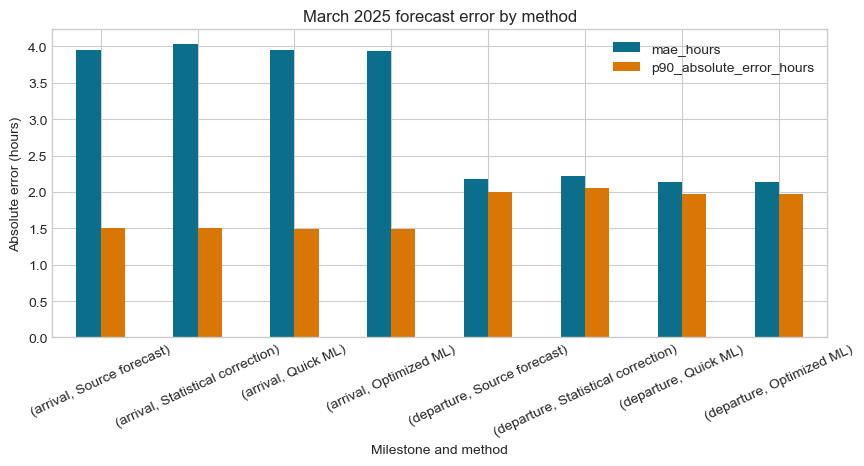

In [8]:
chart_data = comparison.set_index(['milestone', 'method'])[['mae_hours', 'p90_absolute_error_hours']]
ax = chart_data.plot.bar(figsize=(10, 4), color=['#0b6e8a', '#d97706'])
ax.set_title('March 2025 forecast error by method')
ax.set_xlabel('Milestone and method')
ax.set_ylabel('Absolute error (hours)')
ax.tick_params(axis='x', rotation=25)
figure = ax.get_figure()
buffer = BytesIO()
figure.savefig(buffer, format='png', bbox_inches='tight')
plt.close(figure)
image_data = b64encode(buffer.getvalue()).decode()
display(HTML(f'<img alt="Grouped bar chart comparing MAE and P90 absolute error for source, statistical, Quick ML, and Optimized ML forecasts by milestone." src="data:image/png;base64,{image_data}">'))

## 5. Segment and error review

Horizon-band results show where each correction changes the source error. The final table retains source lineage for the largest Optimized ML errors so unusual cases can be traced back to the published snapshot.

In [9]:
segment_rows = []
for (milestone, horizon_band), segment in test_predictions.groupby(
    ['milestone', 'forecast_horizon_band'], observed=True
):
    for method, prediction_column in method_columns.items():
        absolute_error = (
            segment['actual_time'] - segment[prediction_column]
        ).dt.total_seconds().abs() / 3600
        segment_rows.append({
            'milestone': milestone,
            'forecast_horizon_band': horizon_band,
            'method': method,
            'n': len(segment),
            'mae_hours': absolute_error.mean(),
            'p90_absolute_error_hours': absolute_error.quantile(0.90),
        })

segment_comparison = pd.DataFrame(segment_rows)
display(segment_comparison.style.format({
    'n': '{:,.0f}',
    'mae_hours': '{:.2f}',
    'p90_absolute_error_hours': '{:.2f}',
}))

,milestone,forecast_horizon_band,method,n,mae_hours,p90_absolute_error_hours
0,arrival,negative,Source forecast,4,2.04,4.45
1,arrival,negative,Statistical correction,4,2.04,4.45
2,arrival,negative,Quick ML,4,1.98,4.41
3,arrival,negative,Optimized ML,4,1.91,4.12
4,arrival,0–24 hours,Source forecast,767,0.67,1.69
5,arrival,0–24 hours,Statistical correction,767,0.65,1.58
6,arrival,0–24 hours,Quick ML,767,0.66,1.68
7,arrival,0–24 hours,Optimized ML,767,0.65,1.67
8,arrival,24–72 hours,Source forecast,360,1.64,3.25
9,arrival,24–72 hours,Statistical correction,360,1.89,3.96


In [10]:
test_predictions['source_absolute_error_hours'] = test_predictions['target_residual_hours'].abs()
test_predictions['optimized_ml_absolute_error_hours'] = (
    test_predictions['actual_time'] - test_predictions['optimized_ml_adjusted_forecast_time']
).dt.total_seconds().abs() / 3600
largest_optimized_ml_errors = (
    test_predictions.nlargest(10, 'optimized_ml_absolute_error_hours')
    [[
        'canonical_event_id', 'milestone', 'port_code', 'vessel_type_code',
        'forecast_horizon_band', 'forecast_recorded_time', 'forecast_time', 'actual_time',
        'target_residual_hours', 'optimized_ml_residual_hours', 'source_absolute_error_hours',
        'optimized_ml_absolute_error_hours', 'source_chunk', 'response_index', 'area_sequence',
    ]]
)
display(largest_optimized_ml_errors.style.format({
    'target_residual_hours': '{:+.2f}',
    'optimized_ml_residual_hours': '{:+.2f}',
    'source_absolute_error_hours': '{:.2f}',
    'optimized_ml_absolute_error_hours': '{:.2f}',
}))

,canonical_event_id,milestone,port_code,vessel_type_code,forecast_horizon_band,forecast_recorded_time,forecast_time,actual_time,target_residual_hours,optimized_ml_residual_hours,source_absolute_error_hours,optimized_ml_absolute_error_hours,source_chunk,response_index,area_sequence
44,04f9345e18e2c03c,arrival,FISKV,80,7+ days,2025-02-28 07:09:53+00:00,2026-02-02 02:17:00+00:00,2025-03-02 06:30:00+00:00,-8083.78,-0.00,8083.78,8083.78,port_calls__20250302T000000Z__20250303T000000Z.json,54,1
3958,a7d159c6a1806f8c,departure,FITKU,91,7+ days,2025-01-23 16:58:00+00:00,2025-01-31 10:00:00+00:00,2025-03-31 08:20:00+00:00,+1414.33,-0.11,1414.33,1414.44,port_calls__20250123T000000Z__20250124T000000Z.json,76,1
4337,d289b08b1a773f48,departure,FISTR,91,7+ days,2025-01-17 06:57:14+00:00,2025-01-31 15:00:00+00:00,2025-03-31 09:00:00+00:00,+1410.00,-0.04,1410.00,1410.04,port_calls__20250117T000000Z__20250118T000000Z.json,76,1
4470,df2d077a3d2312e1,departure,FINLI,70,7+ days,2025-02-26 09:50:59+00:00,2025-03-11 06:00:00+00:00,2025-03-07 15:10:00+00:00,-86.83,-0.09,86.83,86.74,port_calls__20250218T000000Z__20250219T000000Z.json,43,1
2421,01c01eb70f493701,departure,FIANK,70,24–72 hours,2025-03-20 07:22:14+00:00,2025-03-22 19:00:00+00:00,2025-03-20 11:50:00+00:00,-55.17,-0.11,55.17,55.05,port_calls__20250319T000000Z__20250320T000000Z.json,102,1
3426,707eb62c0cbd2c62,departure,FIKTK,50,3–7 days,2025-02-26 07:13:12+00:00,2025-03-03 20:00:00+00:00,2025-03-05 17:15:00+00:00,+45.25,-0.06,45.25,45.31,port_calls__20250303T000000Z__20250304T000000Z.json,49,1
4522,e4bbb879e7f7e747,departure,FIRAU,70,0–24 hours,2025-03-20 07:30:04+00:00,2025-03-20 22:00:00+00:00,2025-03-22 12:30:00+00:00,+38.50,+0.05,38.50,38.45,port_calls__20250320T000000Z__20250321T000000Z.json,71,1
683,4733cff22ac9fdea,arrival,FIKTK,70,3–7 days,2025-03-02 20:28:34+00:00,2025-03-05 23:00:00+00:00,2025-03-04 13:10:00+00:00,-33.83,+0.20,33.83,34.03,port_calls__20250304T000000Z__20250305T000000Z.json,71,1
3903,a0d265e297d6daa7,departure,FIANK,70,3–7 days,2025-03-02 20:17:43+00:00,2025-03-05 21:00:00+00:00,2025-03-04 12:00:00+00:00,-33.00,-0.11,33.00,32.89,port_calls__20250304T000000Z__20250305T000000Z.json,70,1
3010,4023d54268896873,departure,FIANK,70,3–7 days,2025-03-14 06:03:10+00:00,2025-03-17 18:00:00+00:00,2025-03-16 11:35:00+00:00,-30.42,-0.33,30.42,30.09,port_calls__20250314T000000Z__20250315T000000Z.json,75,1


## Findings and limits

- Quick ML is fixed at `absolute_error`, learning rate 0.05, 15 leaf nodes, 30 minimum samples per leaf, and L2 regularization 1.0. It is fitted on January–February without a search.
- The 16-configuration search selects learning rate 0.03, 15 leaf nodes, 50 minimum samples per leaf, and L2 regularization 1.0 for arrival (February MAE 0.58 hours). Departure selects 0.08, 15, 20, and 0.0 respectively (February MAE 1.56 hours). March is not used in the search.
- On 2,408 March arrival events, source, Quick ML, and Optimized ML produce MAE of 3.96, 3.95, and 3.94 hours; median absolute error of 0.08, 0.07, and 0.06; and P90 of 1.50, 1.49, and 1.49. Optimized ML changes the within-12-hour rate from Quick ML's 99.21% to 99.29%.
- On 2,375 March departure events, Quick and Optimized ML both report 2.14-hour MAE, 0.07-hour median absolute error, and 1.97-hour P90 at two-decimal precision. Unrounded, Optimized ML is worse than Quick by 0.001, 0.005, and 0.008 hours respectively, while its within-24-hour rate increases from 99.28% to 99.33%.
- The statistical correction improves the median error but does not improve MAE or P90 consistently. The train-only fallback is used for 74 arrival evaluation events (3.07%) and 75 departure evaluation events (3.16%) whose group lookup has no training match.
- Optimization adds rare-category handling, transformed features, and 16 model fits per milestone for negligible March improvement over Quick ML. This quarter does not justify the extra complexity.
- One arrival source forecast has an 8,083.78-hour error. It remains in the evaluation without target clipping, winsorization, or row removal, so MAE is sensitive to this source anomaly while median and P90 remain low.
- This Q1 evaluation uses one retained forecast state per source row and does not establish production generalisation. Source timestamp semantics and the non-monotonic horizon pattern from Notebook 03 remain unresolved.
- The models estimate source residuals; no proprietary model accuracy, customer cost, delay prevention, detention, demurrage, or business impact is inferred.